## ```sampley``` tests - Stage 2 (Periods, Cells, Segments, Presences, PresenceZones, and Absences)

### Setup

In [1]:
from sampley import *
import matplotlib.pyplot as plt

In [2]:
import_folder = './import/'
export_folder = './export/'

In [3]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [4]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


In [5]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    geometry_col='geometry',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)

Success: file opened.
Success: geometries parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


In [6]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    datetime_format='%Y-%m-%d %H:%M:%S',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
    datapoint_id_col='datapoint_id',
    section_id_col='section_id'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


In [7]:
u_trackpoints.name

'datapoints-trackpoints'

In [8]:
u_trackpoints.parameters

{'datapoints_filepath': './import/trackpoints.csv',
 'datapoints_crs': 'EPSG:32619',
 'datapoints_tz': 'UTC-06:00',
 'datapoints_data_cols': 'section_id, individuals, bss, season'}

In [9]:
u_trackpoints.datapoints

,datapoint_id,section_id,geometry,datetime,individuals,bss,season
0,dp0001,s001,POINT (580092.757 4742883.408),2019-01-25 09:18:13-06:00,NaN,2,winter
1,dp0002,s001,POINT (579997.135 4742882.297),2019-01-25 09:18:15-06:00,NaN,2,winter
2,dp0003,s001,POINT (579616.283 4742877.883),2019-01-25 09:18:23-06:00,NaN,2,winter
3,dp0004,s001,POINT (579166.78 4742872.701),2019-01-25 09:18:32-06:00,1.0,2,winter
4,dp0005,s001,POINT (578880.732 4742869.419),2019-01-25 09:18:38-06:00,NaN,2,winter
...,...,...,...,...,...,...,...
1762,dp1763,s004,POINT (603283.221 4696803.55),2019-03-05 12:09:25-06:00,NaN,3,spring
1763,dp1764,s004,POINT (602912.975 4696798.087),2019-03-05 12:09:33-06:00,NaN,3,spring
1764,dp1765,s004,POINT (602582.514 4696885.41),2019-03-05 12:09:41-06:00,NaN,3,spring
1765,dp1766,s004,POINT (602458.009 4696957.996),2019-03-05 12:09:45-06:00,NaN,3,spring


In [10]:
u_trackpoints.save(
    folder=export_folder, 
    crs_export='EPSG:4326', 
    tz_export='UTC-05:00')

Success: reprojected to CRS "EPSG:4326"
Success: column "datetime" converted to timezone "UTC-05:00"


In [11]:
u_trackpoints = DataPoints.open(
    export_folder, 
    basename='datapoints-trackpoints', 
    crs_working='EPSG:32619',
    tz_working='UTC-06:00')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Note: the inherent (contained within the datetimes) timezone of column "datetime" is "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


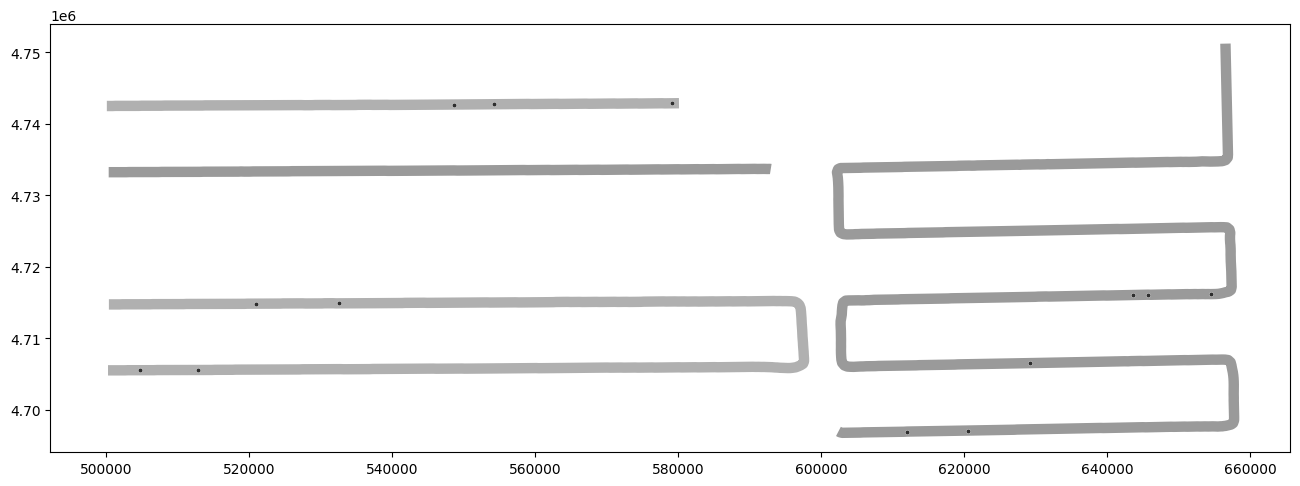

In [12]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_sightings.plot(sections=u_sections)

In [13]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


In [14]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    datetime_format='%Y-%m-%d %H:%M:%S',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
    section_id_col='section_id'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


In [15]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(
    datapoints=u_trackpoints,
    cols={'bss': 'mean', 'season': 'first', 'datetime': 'first'},
    sortby='datetime')

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [16]:
u_sections.name

'sections-trackpoints'

In [17]:
u_sections.parameters

{'sections_filepath': './import/trackpoints.csv (via datapoints)',
 'sections_crs': 'EPSG:32619',
 'sections_tz': 'UTC-05:00'}

In [18]:
u_sections.sections

,section_id,geometry,datetime,bss,season
0,s001,"LINESTRING (580092.757 4742883.408, 579997.135...",2019-01-25 10:18:13-05:00,2.398058,winter
1,s002,"LINESTRING (592927.566 4733678.432, 592818.466...",2019-01-30 14:32:57-05:00,3.000000,winter
2,s003,"LINESTRING (500383.195 4714750.316, 500765.569...",2019-03-02 12:43:27-05:00,1.537864,spring
3,s004,"LINESTRING (656499.299 4751214.73, 656509.418 ...",2019-03-05 11:21:16-05:00,1.280872,spring


In [19]:
u_sections.save(
    folder=export_folder, 
    crs_export='EPSG:4326', 
    tz_export='UTC-05:00')

Success: reprojected to CRS "EPSG:4326"
Note: conversion of column "datetime" to timezone "UTC-05:00" not necessary as already in timezone "UTC-05:00".


In [20]:
u_sections = Sections.open(
    export_folder, 
    basename='sections-trackpoints', 
    crs_working='EPSG:32619',
    tz_working='UTC-06:00')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Note: the inherent (contained within the datetimes) timezone of column "datetime" is "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"


Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


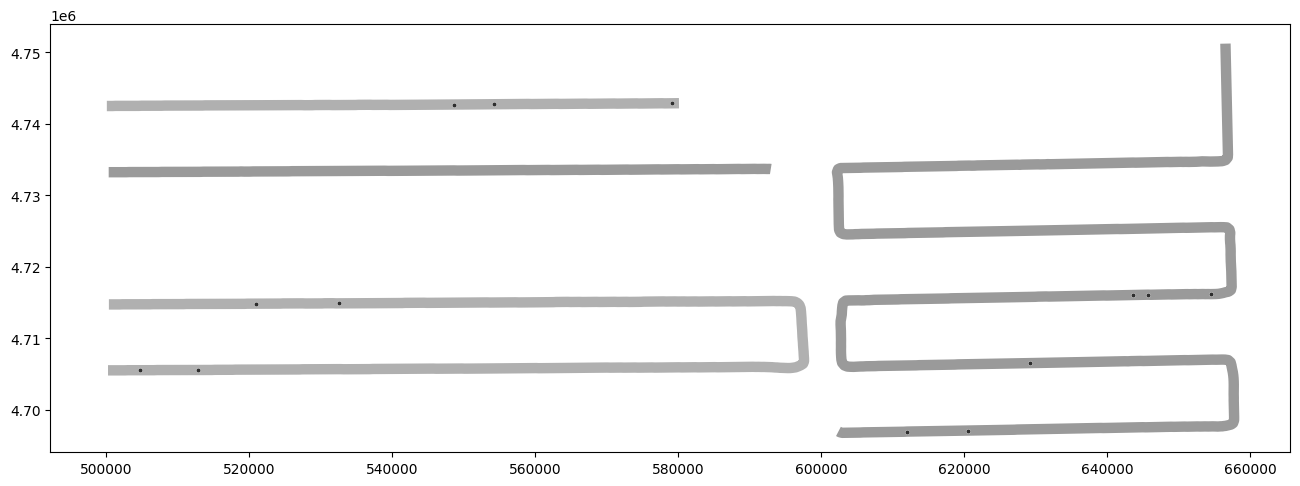

In [21]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections.plot(datapoints=u_sightings)

### Periods

#### ```Periods.delimit```

##### Custom extent

In [22]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-03-03 14:32:57'], 'UTC-05:00'),
    unit='day',
    num=8)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-05:00,2019-01-29 00:00:00-05:00,2019-02-01 00:00:00-05:00
1,p2019-02-02-8d,2019-02-02 00:00:00-05:00,2019-02-06 00:00:00-05:00,2019-02-09 00:00:00-05:00
2,p2019-02-10-8d,2019-02-10 00:00:00-05:00,2019-02-14 00:00:00-05:00,2019-02-17 00:00:00-05:00
3,p2019-02-18-8d,2019-02-18 00:00:00-05:00,2019-02-22 00:00:00-05:00,2019-02-25 00:00:00-05:00
4,p2019-02-26-8d,2019-02-26 00:00:00-05:00,2019-03-02 00:00:00-05:00,2019-03-05 00:00:00-05:00


In [23]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-10-03 14:32:57'], 'UTC-05:00'),
    unit='month',
    num=2)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-2m,2019-01-01 00:00:00-05:00,2019-01-30 00:00:00-05:00,2019-02-28 00:00:00-05:00
1,p2019-03-01-2m,2019-03-01 00:00:00-05:00,2019-03-31 00:00:00-05:00,2019-04-30 00:00:00-05:00
2,p2019-05-01-2m,2019-05-01 00:00:00-05:00,2019-05-31 00:00:00-05:00,2019-06-30 00:00:00-05:00
3,p2019-07-01-2m,2019-07-01 00:00:00-05:00,2019-08-01 00:00:00-05:00,2019-08-31 00:00:00-05:00
4,p2019-09-01-2m,2019-09-01 00:00:00-05:00,2019-10-01 00:00:00-05:00,2019-10-31 00:00:00-05:00


In [24]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2023-10-03 14:32:57'], 'UTC-05:00'),
    unit='year',
    num=1)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-1y,2019-01-01 00:00:00-05:00,2019-07-02 00:00:00-05:00,2019-12-31 00:00:00-05:00
1,p2020-01-01-1y,2020-01-01 00:00:00-05:00,2020-07-02 00:00:00-05:00,2020-12-31 00:00:00-05:00
2,p2021-01-01-1y,2021-01-01 00:00:00-05:00,2021-07-02 00:00:00-05:00,2021-12-31 00:00:00-05:00
3,p2022-01-01-1y,2022-01-01 00:00:00-05:00,2022-07-02 00:00:00-05:00,2022-12-31 00:00:00-05:00
4,p2023-01-01-1y,2023-01-01 00:00:00-05:00,2023-07-02 00:00:00-05:00,2023-12-31 00:00:00-05:00


In [25]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-03-03 14:32:57'], None),
    unit='day',
    num=8)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25,2019-01-29,2019-02-01
1,p2019-02-02-8d,2019-02-02,2019-02-06,2019-02-09
2,p2019-02-10-8d,2019-02-10,2019-02-14,2019-02-17
3,p2019-02-18-8d,2019-02-18,2019-02-22,2019-02-25
4,p2019-02-26-8d,2019-02-26,2019-03-02,2019-03-05


In [26]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-10-03 14:32:57'], None),
    unit='month',
    num=2)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-2m,2019-01-01,2019-01-30,2019-02-28
1,p2019-03-01-2m,2019-03-01,2019-03-31,2019-04-30
2,p2019-05-01-2m,2019-05-01,2019-05-31,2019-06-30
3,p2019-07-01-2m,2019-07-01,2019-08-01,2019-08-31
4,p2019-09-01-2m,2019-09-01,2019-10-01,2019-10-31


In [27]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2023-10-03 14:32:57'], None),
    unit='year',
    num=1)
u_periods.periods

Success: column "datetime" reformatted to datetimes.
Note: timezone of column "datetime" was not set as no timezone was specified.


,period_id,date_beg,date_mid,date_end
0,p2019-01-01-1y,2019-01-01,2019-07-02,2019-12-31
1,p2020-01-01-1y,2020-01-01,2020-07-02,2020-12-31
2,p2021-01-01-1y,2021-01-01,2021-07-02,2021-12-31
3,p2022-01-01-1y,2022-01-01,2022-07-02,2022-12-31
4,p2023-01-01-1y,2023-01-01,2023-07-02,2023-12-31


##### Extent based on DataPoints

In [28]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00'
)
u_periods = Periods.delimit(
    extent=u_trackpoints,
    unit='day',
    num=8)
u_periods.periods

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"
Success: datapoint IDs generated.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


##### Extent based on Sections

In [29]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    tz_working='UTC-06:00',
)
u_periods = Periods.delimit(
    extent=u_sections,
    unit='day',
    num=8)
u_periods.periods

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: column "datetime" converted to timezone "UTC-06:00"
Success: section IDs generated.


,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


#### Periods attributes

In [30]:
u_periods.name

'periods-8d'

In [31]:
u_periods.parameters

{'periods_tz': 'UTC-06:00',
 'periods_extent': '2019-01-25-2019-03-05',
 'periods_extent_source': 'Sections - sections-sections',
 'periods_number': 8,
 'periods_unit': 'day'}

In [32]:
u_periods.periods

,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-06:00,2019-01-29 00:00:00-06:00,2019-02-01 00:00:00-06:00
1,p2019-02-02-8d,2019-02-02 00:00:00-06:00,2019-02-06 00:00:00-06:00,2019-02-09 00:00:00-06:00
2,p2019-02-10-8d,2019-02-10 00:00:00-06:00,2019-02-14 00:00:00-06:00,2019-02-17 00:00:00-06:00
3,p2019-02-18-8d,2019-02-18 00:00:00-06:00,2019-02-22 00:00:00-06:00,2019-02-25 00:00:00-06:00
4,p2019-02-26-8d,2019-02-26 00:00:00-06:00,2019-03-02 00:00:00-06:00,2019-03-05 00:00:00-06:00


#### ```Periods.save```

In [33]:
u_periods.save(folder=export_folder)

#### ```Periods.open```

In [34]:
u_periods = Periods.open(
    export_folder, 
    basename='periods-8d')  

Success: file opened.
Success: file opened.


### Cells

#### ```Cells.delimit```

##### Custom extent

In [35]:
from pyproj import CRS
u_cells = Cells.delimit(
    extent=([500095.61955057, 4696798.08683991, 657711.42048071, 4751214.73038492], CRS('EPSG:32619')),
    var='hexagonal',
    side=5000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


In [36]:
from pyproj import CRS
u_cells = Cells.delimit(
    extent=([500095.61955057, 4696798.08683991, 657711.42048071, 4751214.73038492], CRS('EPSG:32619')),
    var='rectangular',
    side=5000,
    buffer=2000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((498095.62 4694798.087, 503095.62 469...",POINT (500595.62 4697298.087)
1,c002-r5000m,"POLYGON ((503095.62 4694798.087, 508095.62 469...",POINT (505595.62 4697298.087)
2,c003-r5000m,"POLYGON ((508095.62 4694798.087, 513095.62 469...",POINT (510595.62 4697298.087)
3,c004-r5000m,"POLYGON ((513095.62 4694798.087, 518095.62 469...",POINT (515595.62 4697298.087)
4,c005-r5000m,"POLYGON ((518095.62 4694798.087, 523095.62 469...",POINT (520595.62 4697298.087)
...,...,...,...
391,c392-r5000m,"POLYGON ((638095.62 4749798.087, 643095.62 474...",POINT (640595.62 4752298.087)
392,c393-r5000m,"POLYGON ((643095.62 4749798.087, 648095.62 474...",POINT (645595.62 4752298.087)
393,c394-r5000m,"POLYGON ((648095.62 4749798.087, 653095.62 474...",POINT (650595.62 4752298.087)
394,c395-r5000m,"POLYGON ((653095.62 4749798.087, 658095.62 474...",POINT (655595.62 4752298.087)


##### Extent based on polygon

In [37]:
import geopandas as gpd  # import geopandas package
study_area = gpd.read_file(import_folder + 'study_area.gpkg')  # import the GeoPackage as a GeoDataFrame
u_cells = Cells.delimit(
    extent=study_area,
    var='hexagonal',
    side=5000)
u_cells.cells

,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on DataPoints

In [38]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    geometry_col='geometry',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    section_id_col='section_id'
)
u_cells = Cells.delimit(
    extent=u_trackpoints,
    var='hexagonal',
    side=5000)
u_cells.cells

Success: file opened.
Success: geometries parsed.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.


,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on Sections

In [39]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_cells = Cells.delimit(
    extent=u_sections,
    var='hexagonal',
    side=5000)
u_cells.cells

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((500095.62 4701798.087, 504425.747 46...",POINT (500095.62 4696798.087)
1,c002-h5000m,"POLYGON ((508755.874 4701798.087, 513086.001 4...",POINT (508755.874 4696798.087)
2,c003-h5000m,"POLYGON ((517416.128 4701798.087, 521746.255 4...",POINT (517416.128 4696798.087)
3,c004-h5000m,"POLYGON ((526076.382 4701798.087, 530406.509 4...",POINT (526076.382 4696798.087)
4,c005-h5000m,"POLYGON ((534736.636 4701798.087, 539066.763 4...",POINT (534736.636 4696798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((629999.43 4761798.087, 634329.557 47...",POINT (629999.43 4756798.087)
176,c177-h5000m,"POLYGON ((638659.684 4761798.087, 642989.811 4...",POINT (638659.684 4756798.087)
177,c178-h5000m,"POLYGON ((647319.938 4761798.087, 651650.065 4...",POINT (647319.938 4756798.087)
178,c179-h5000m,"POLYGON ((655980.192 4761798.087, 660310.319 4...",POINT (655980.192 4756798.087)


##### Extent based on polygon with coarse

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


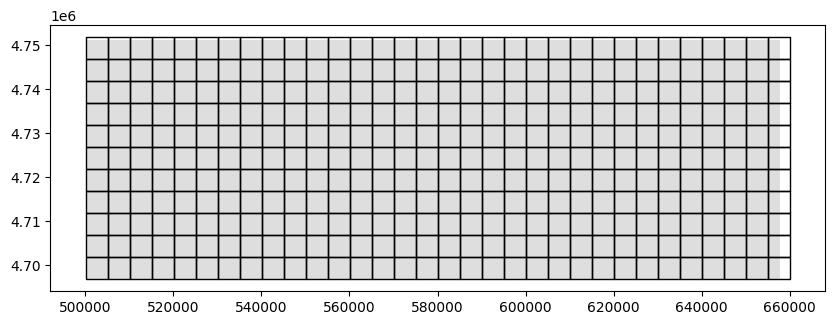

In [40]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    coarse=5,
    select='intersects')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

##### Extent based on polygon with select options

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


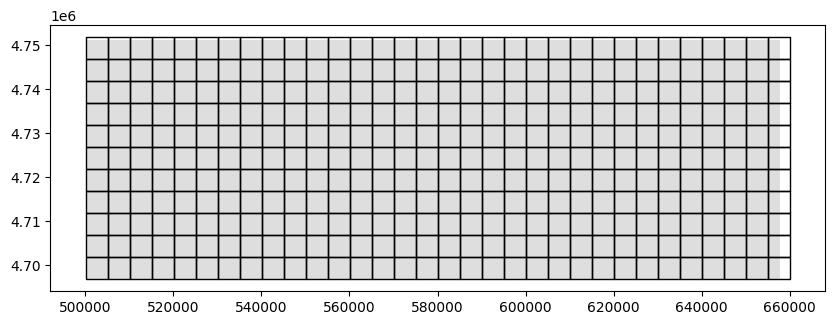

In [41]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='intersects')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
305,c306-r5000m,"POLYGON ((630095.62 4741798.087, 635095.62 474...",POINT (632595.62 4744298.087)
306,c307-r5000m,"POLYGON ((635095.62 4741798.087, 640095.62 474...",POINT (637595.62 4744298.087)
307,c308-r5000m,"POLYGON ((640095.62 4741798.087, 645095.62 474...",POINT (642595.62 4744298.087)
308,c309-r5000m,"POLYGON ((645095.62 4741798.087, 650095.62 474...",POINT (647595.62 4744298.087)


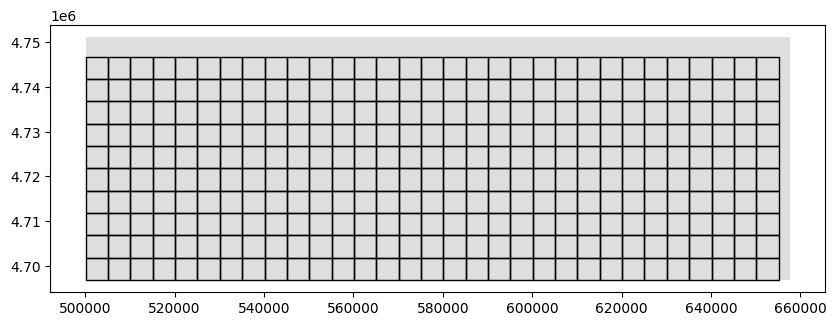

In [42]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='within')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


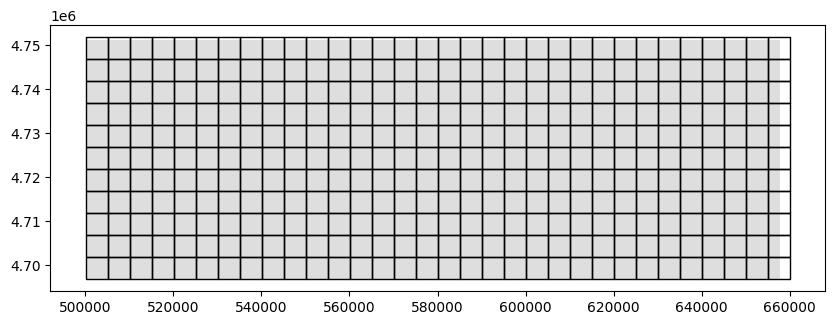

In [43]:
u_cells = Cells.delimit(
    extent=study_area,
    var='rectangular',
    side=5000,
    select='centroid')
fig, ax = plt.subplots(figsize=(10, 6))
study_area.plot(ax=ax, facecolor='#dedede', zorder=0)
u_cells.cells.plot(ax=ax, facecolor='none')
u_cells.cells

#### Cells attributes

In [44]:
u_cells.name

'cells-r5000m'

In [45]:
u_cells.parameters

{'cells_crs': 'EPSG:32619',
 'cells_extent': '500095.6195505685, 4696798.086839909, 660095.6195505685, 4751798.086839909',
 'cells_extent_source': 'GeoDataFrame',
 'cells_var': 'rectangular',
 'cells_side': 5000,
 'cells_unit': 'metre',
 'cells_buffer': None}

In [46]:
u_cells.cells

,cell_id,polygon,centroid
0,c001-r5000m,"POLYGON ((500095.62 4696798.087, 505095.62 469...",POINT (502595.62 4699298.087)
1,c002-r5000m,"POLYGON ((505095.62 4696798.087, 510095.62 469...",POINT (507595.62 4699298.087)
2,c003-r5000m,"POLYGON ((510095.62 4696798.087, 515095.62 469...",POINT (512595.62 4699298.087)
3,c004-r5000m,"POLYGON ((515095.62 4696798.087, 520095.62 469...",POINT (517595.62 4699298.087)
4,c005-r5000m,"POLYGON ((520095.62 4696798.087, 525095.62 469...",POINT (522595.62 4699298.087)
...,...,...,...
347,c348-r5000m,"POLYGON ((635095.62 4746798.087, 640095.62 474...",POINT (637595.62 4749298.087)
348,c349-r5000m,"POLYGON ((640095.62 4746798.087, 645095.62 474...",POINT (642595.62 4749298.087)
349,c350-r5000m,"POLYGON ((645095.62 4746798.087, 650095.62 474...",POINT (647595.62 4749298.087)
350,c351-r5000m,"POLYGON ((650095.62 4746798.087, 655095.62 474...",POINT (652595.62 4749298.087)


#### ```Cells.save```

In [47]:
u_cells.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: additional geometry column "centroid" reprojected to CRS "EPSG:4326"
Success: reprojected to CRS "EPSG:4326"


#### ```Cells.open```

In [48]:
u_cells = Cells.open(
    export_folder, 
    basename='cells-r5000m', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: file opened.
Success: additional geometry column "centroid" reprojected to CRS "EPSG:32619"
Success: reprojected to CRS "EPSG:32619"


#### ```Cells.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


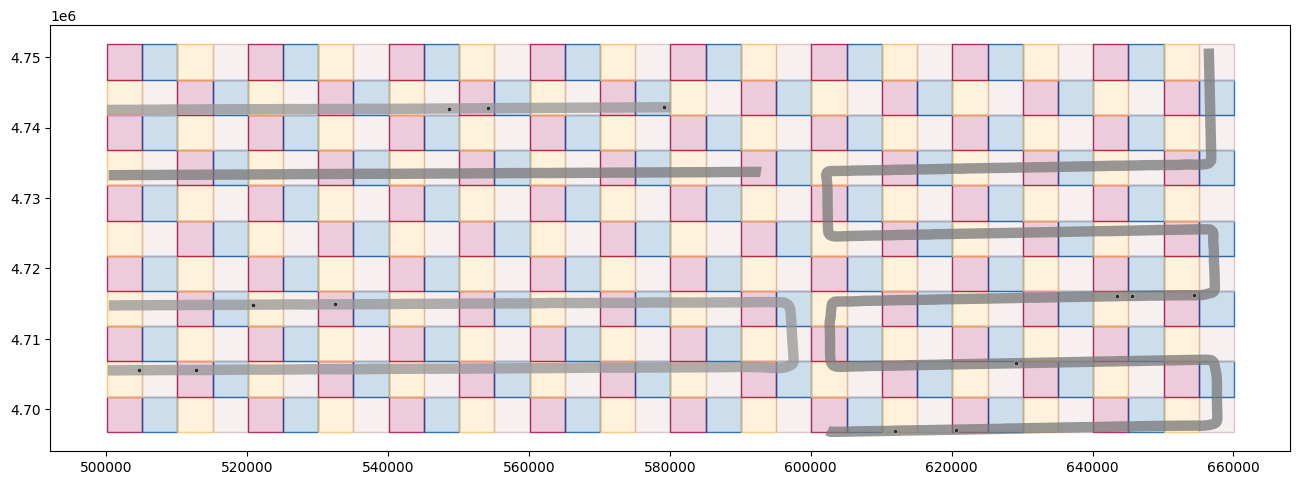

In [49]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_cells.plot(datapoints=u_sightings, sections=u_sections)

### Segments

#### ```Segments.delimit```

##### Simple variation - not randomised

In [50]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='simple',
    target=10000)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-s10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.0,10000.000000
1,s02-s10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.0,20000.000000
2,s03-s10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),None,s1,20000.0,30000.000000
3,s04-s10000m,"LINESTRING (550095.667 4742710.935, 549838.842...",POINT (545095.787 4742676.383),None,s1,30000.0,40000.000000
4,s05-s10000m,"LINESTRING (540095.882 4742645.456, 539704.822...",POINT (535096.832 4742648.569),None,s1,40000.0,50000.000000
...,...,...,...,...,...,...,...
68,s69-s10000m,"LINESTRING (646445.51 4697592.665, 646369.277 ...",POINT (641446.66 4697508.557),None,s4,280000.0,290000.000000
69,s70-s10000m,"LINESTRING (636447.691 4697428.025, 636124.889...",POINT (631448.609 4697332.185),None,s4,290000.0,300000.000000
70,s71-s10000m,"LINESTRING (626450.303 4697221.055, 626265.927...",POINT (621451.09 4697132.369),None,s4,300000.0,310000.000000
71,s72-s10000m,"LINESTRING (616451.814 4697047.259, 616228.106...",POINT (611453.214 4696946.859),None,s4,310000.0,320000.000000


##### Simple variation - randomised

In [51]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='simple',
    target=10000,
    rand=True)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-s10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.000000,10000.000000
1,s02-s10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.000000,20000.000000
2,s03-s10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),None,s1,20000.000000,30000.000000
3,s04-s10000m,"LINESTRING (550095.667 4742710.935, 549838.842...",POINT (545095.787 4742676.383),None,s1,30000.000000,40000.000000
4,s05-s10000m,"LINESTRING (540095.882 4742645.456, 539704.822...",POINT (535096.832 4742648.569),None,s1,40000.000000,50000.000000
...,...,...,...,...,...,...,...
68,s69-s10000m,"LINESTRING (652338.76 4697682.02, 652197.878 4...",POINT (647339.987 4697611.472),None,s4,274105.324868,284105.324868
69,s70-s10000m,"LINESTRING (642341.15 4697526.723, 641994.147 ...",POINT (637342.194 4697445.552),None,s4,284105.324868,294105.324868
70,s71-s10000m,"LINESTRING (632343.125 4697349.07, 632326.134 ...",POINT (627344.065 4697254.461),None,s4,294105.324868,304105.324868
71,s72-s10000m,"LINESTRING (622345.629 4697147.973, 622000.67 ...",POINT (617346.364 4697062.225),None,s4,304105.324868,314105.324868


##### Joining variation

In [52]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='joining',
    target=10000,
    rand=True)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-j10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),None,s1,0.000000,10000.000000
1,s02-j10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),None,s1,10000.000000,20000.000000
2,s03-j10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555093.2 4742749.1),None,s1,20000.000000,30004.642260
3,s04-j10000m,"LINESTRING (550091.025 4742710.901, 549838.842...",POINT (545091.144 4742676.352),None,s1,30004.642260,40004.642260
4,s05-j10000m,"LINESTRING (540091.24 4742645.429, 539704.822 ...",POINT (535092.196 4742648.323),None,s1,40004.642260,50004.642260
...,...,...,...,...,...,...,...
64,s65-j10000m,"LINESTRING (652338.76 4697682.02, 652197.878 4...",POINT (647339.987 4697611.472),None,s4,274105.324868,284105.324868
65,s66-j10000m,"LINESTRING (642341.15 4697526.723, 641994.147 ...",POINT (637342.194 4697445.552),None,s4,284105.324868,294105.324868
66,s67-j10000m,"LINESTRING (632343.125 4697349.07, 632326.134 ...",POINT (627344.065 4697254.461),None,s4,294105.324868,304105.324868
67,s68-j10000m,"LINESTRING (622345.629 4697147.973, 622000.67 ...",POINT (617346.364 4697062.225),None,s4,304105.324868,314105.324868


##### Redistribution variation

In [53]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments = Segments.delimit(
    sections=u_sections,
    var='redistribution',
    target=10000)
u_segments.segments

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),None,s1,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),None,s1,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),None,s1,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),None,s1,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),None,s1,40002.321130,50002.901413
...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),None,s4,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),None,s4,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),None,s4,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),None,s4,303848.742064,313977.033466


#### ```Segments.datetimes```

In [54]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(datapoints=u_trackpoints)
u_segments = Segments.delimit(
    sections=u_sections,
    var='redistribution',
    target=10000)
u_segments.datetimes(datapoints=u_trackpoints)
u_segments.segments

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413
...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466


#### Segments attributes

In [55]:
u_segments.name

'segments-r10000m'

In [56]:
u_segments.parameters

{'sections_name': 'sections-trackpoints',
 'segments_crs': 'EPSG:32619',
 'segments_var': 'redistribution',
 'segments_rand': False,
 'segments_target': 10000,
 'segments_unit': 'metre'}

In [57]:
u_segments.segments

,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413
...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466


#### ```Segments.save```

In [58]:
u_segments.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: additional geometry column "midpoint" reprojected to CRS "EPSG:4326"
Success: reprojected to CRS "EPSG:4326"


#### ```Segments.open```

In [59]:
u_segments = Segments.open(
    export_folder, 
    basename='segments-r10000m', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: file opened.
Success: additional geometry column "midpoint" reprojected to CRS "EPSG:32619"
Success: reprojected to CRS "EPSG:32619"


#### ```Segments.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


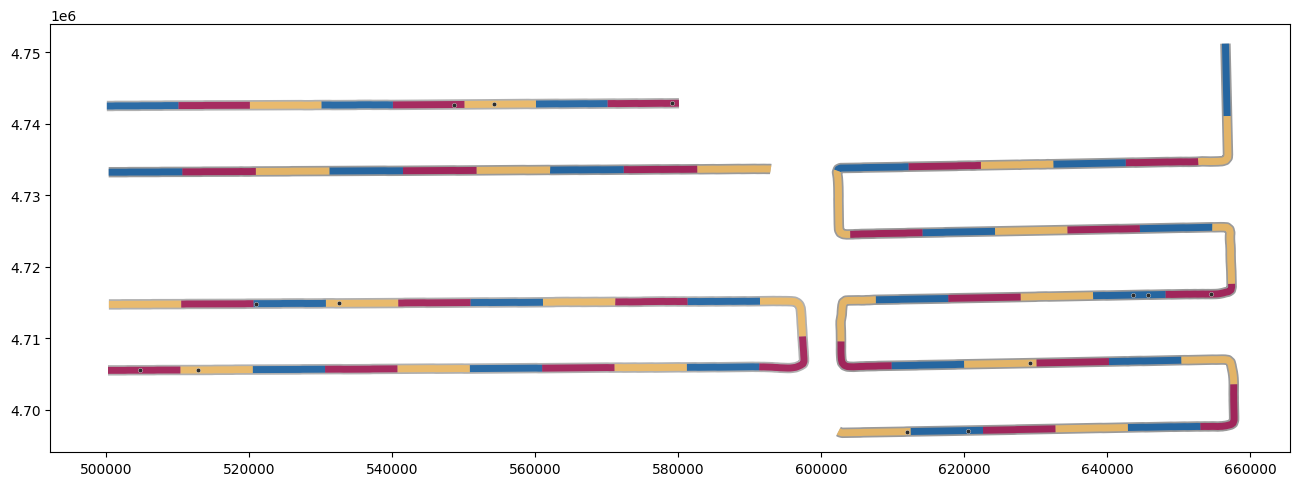

In [60]:
u_sightings = DataPoints.from_file(filepath=import_folder+'sightings.gpkg', crs_working='EPSG:32619')
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_segments.plot(datapoints=u_sightings, sections=u_sections)

### Presences

#### ```Presences.delimit```

In [61]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')
u_presences.presences

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,point_id,point,date,datapoint_id
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10


In [62]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals',
    block='season')
u_presences.presences

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


,point_id,point,date,datapoint_id,season
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01,winter
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02,winter
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03,winter
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04,spring
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05,spring
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06,spring
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07,spring
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08,spring
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09,spring
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10,spring


#### Presences attributes

In [63]:
u_presences.name

'presences-sightings'

In [64]:
u_presences.parameters

{'presences_crs': 'EPSG:32619'}

In [65]:
u_presences.presences

,point_id,point,date,datapoint_id,season
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01,winter
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02,winter
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03,winter
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04,spring
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05,spring
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06,spring
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07,spring
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08,spring
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09,spring
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10,spring


#### ```Presences.save```

In [66]:
u_presences.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```Presences.open```

In [67]:
u_presences = Presences.open(
    export_folder, 
    basename='presences-sightings', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```Presences.plot```

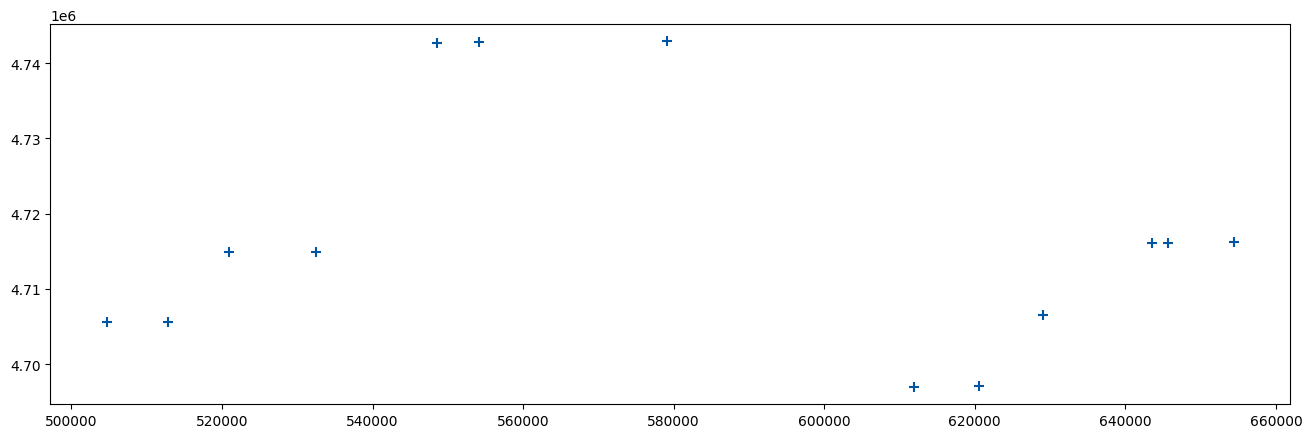

In [68]:
u_presences.plot()

### PresenceZones

#### ```PresenceZones.delimit```

##### Setup

In [69]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


##### Without temporal threshold

In [70]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000
)
u_presencezones.presencezones

,section_id,presencezones
0,all,"MULTIPOLYGON (((506661.313 4695745.539, 505690..."


##### With temporal threshold

In [71]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=0,
    tm_unit='day',
)
u_presencezones.presencezones

,section_id,presencezones
0,s001,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
1,s002,None
2,s003,"POLYGON ((507613.256 4695983.989, 506661.313 4..."
3,s004,"POLYGON ((614879.704 4687404.708, 613927.76 46..."


#### PresenceZones attributes

In [72]:
u_presencezones.name

'presencezones-10000m-0day'

In [73]:
u_presencezones.parameters

{'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 0,
 'presencezones_tm_unit': 'day'}

In [74]:
u_presencezones.presencezones

,section_id,presencezones
0,s001,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
1,s002,None
2,s003,"POLYGON ((507613.256 4695983.989, 506661.313 4..."
3,s004,"POLYGON ((614879.704 4687404.708, 613927.76 46..."


#### ```PresenceZones.save```

In [75]:
u_presencezones.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```PresenceZones.open```

In [76]:
u_presencezones = PresenceZones.open(
    export_folder, 
    basename='presencezones-10000m-0day', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```PresenceZones.plot```

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: section IDs generated.


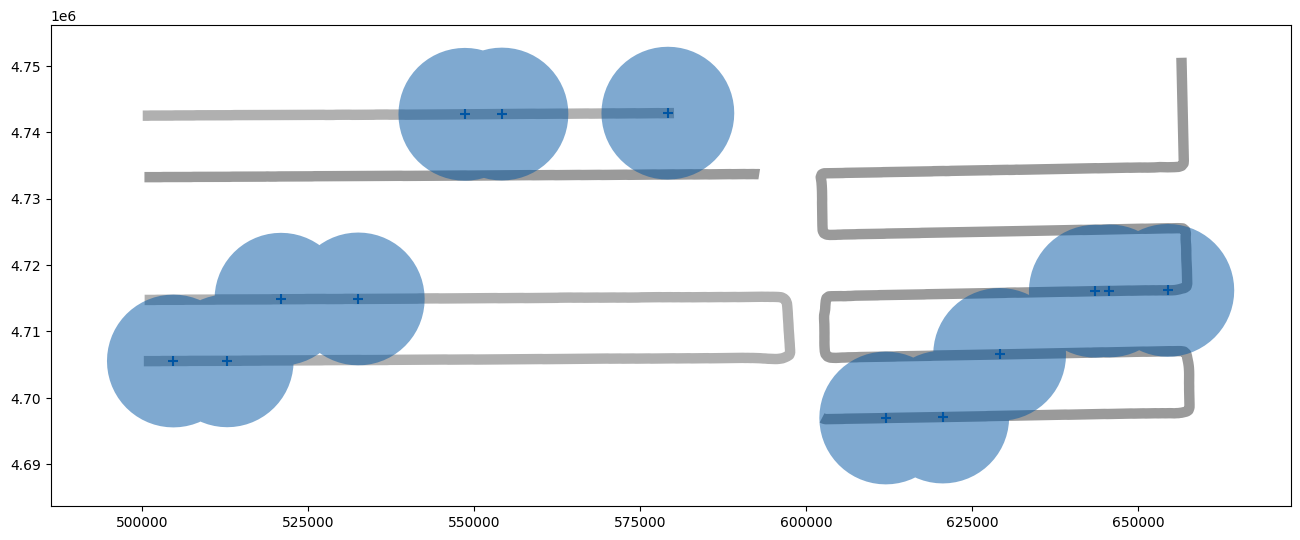

In [77]:
u_sections = Sections.from_file(filepath=import_folder+'sections.gpkg', crs_working='EPSG:32619')
u_presencezones.plot(sections=u_sections, presences=u_presences)

### Absences

#### ```Absences.delimit```

##### Setup

In [78]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'
)
u_sections = Sections.from_datapoints(
    datapoints=u_trackpoints,
    cols={'season': 'first'})
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals',
    block='season')
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=0,
    tm_unit='day'
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


##### Along-the-line variation

###### Without blocks

In [79]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=20,
    limit=2)
u_absences.absences

Target: 20 | Attempts: 24 | Successes: 20


,point_id,point,date,section_id,dfbs
0,a01,POINT (566260.593 4742810.843),2019-01-25,s001,13834.083781
1,a02,POINT (565912.571 4742807.502),2019-01-25,s001,14182.122375
2,a03,POINT (535193.56 4742653.688),2019-01-25,s001,44903.136205
3,a04,POINT (517187.118 4742587.938),2019-01-25,s001,62911.395177
4,a05,POINT (570329.424 4733577.95),2019-01-30,s002,102607.130662
5,a06,POINT (532253.352 4733406.246),2019-01-30,s002,140685.682467
6,a07,POINT (519885.347 4733322.921),2019-01-30,s002,153054.707312
7,a08,POINT (542599.452 4714973.075),2019-03-02,s003,214808.626492
8,a09,POINT (576342.594 4715150.88),2019-03-02,s003,248556.324329
9,a10,POINT (580593.347 4705944.62),2019-03-02,s003,294581.306692


###### With blocks, ```how='target'```

In [80]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=5,
    block='season',
    how='target')
u_absences.absences


Block: winter
Target: 5 | Attempts: 7 | Successes: 5

Block: spring
Target: 5 | Attempts: 6 | Successes: 5


,point_id,point,date,section_id,dfbs,season
0,a01,POINT (501764.848 4742511.197),2019-01-25,s001,78334.974971,winter
1,a02,POINT (586414.412 4733668.29),2019-01-30,s002,86520.267044,winter
2,a03,POINT (560177.191 4733537.561),2019-01-30,s002,112760.434902,winter
3,a04,POINT (541654.393 4733437.666),2019-01-30,s002,131284.191721,winter
4,a05,POINT (536316.606 4733426.416),2019-01-30,s002,136622.377379,winter
5,a06,POINT (580501.928 4715161.186),2019-03-02,s003,80128.498038,spring
6,a07,POINT (528102.697 4705682.873),2019-03-02,s003,174488.885360,spring
7,a08,POINT (608934.557 4724674.444),2019-03-05,s004,288259.892392,spring
8,a09,POINT (623287.488 4715695.461),2019-03-05,s004,379090.097905,spring
9,a10,POINT (612273.835 4715490.952),2019-03-05,s004,390106.063622,spring


###### With blocks, ```how='average'```

In [81]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=10,
    block='season',
    how='average')
u_absences.absences


Block: winter
Target: 5 | Attempts: 6 | Successes: 5

Block: spring
Target: 5 | Attempts: 10 | Successes: 5


,point_id,point,date,section_id,dfbs,season
0,a01,POINT (504177.827 4742512.239),2019-01-25,s001,75921.995455,winter
1,a02,POINT (589626.315 4733690.34),2019-01-30,s002,83307.896139,winter
2,a03,POINT (572687.352 4733602.364),2019-01-30,s002,100249.076674,winter
3,a04,POINT (564565.659 4733558.314),2019-01-30,s002,108371.536705,winter
4,a05,POINT (546432.122 4733468.133),2019-01-30,s002,126506.365675,winter
5,a06,POINT (545641.975 4714973.518),2019-03-02,s003,45263.696665,spring
6,a07,POINT (560133.5 4715047.193),2019-03-02,s003,59756.184643,spring
7,a08,POINT (592542.126 4715217.848),2019-03-02,s003,92170.636303,spring
8,a09,POINT (649110.549 4734662.945),2019-03-05,s004,226165.571397,spring
9,a10,POINT (655977.724 4697706.766),2019-03-05,s004,472797.768648,spring


###### With blocks, ```how='effort'```

In [82]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=100,
    block='season',
    how='effort')
lengths = u_sections.sections.copy()
lengths['length'] = lengths.length
lengths = lengths.groupby('season').agg({'length': 'sum'})
lengths['length_percentage'] = lengths['length'] / sum(lengths['length']) * 100
print('\n', lengths['length_percentage'], '\n')
u_absences.absences


Block: winter
Target: 25 | Attempts: 35 | Successes: 25

Block: spring
Target: 76 | Attempts: 120 | Successes: 76

 season
spring    75.310261
winter    24.689739
Name: length_percentage, dtype: float64 



,point_id,point,date,section_id,dfbs,season
0,a001,POINT (568894.517 4742817.81),2019-01-25,s001,11199.766501,winter
1,a002,POINT (567753.413 4742806.49),2019-01-25,s001,12340.926544,winter
2,a003,POINT (567086.732 4742818.84),2019-01-25,s001,13007.905914,winter
3,a004,POINT (535774.872 4742659.411),2019-01-25,s001,44321.737872,winter
4,a005,POINT (532579.846 4742624.677),2019-01-25,s001,47517.350259,winter
...,...,...,...,...,...,...
96,a097,POINT (645666.07 4697576.369),2019-03-05,s004,483113.028851,spring
97,a098,POINT (644190.779 4697564.651),2019-03-05,s004,484588.725618,spring
98,a099,POINT (639225.449 4697474.236),2019-03-05,s004,489555.100343,spring
99,a100,POINT (639221.903 4697474.323),2019-03-05,s004,489558.647068,spring


###### With blocks, ```how='presences'```

In [83]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=2,
    block='season',
    how='presences',
    presences=u_presences)
print('\n', u_presences.presences['season'].value_counts(), '\n')
u_absences.absences


Block: winter
Target: 6 | Attempts: 7 | Successes: 6

Block: spring
Target: 20 | Attempts: 33 | Successes: 20

 season
spring    10
winter     3
Name: count, dtype: int64 



,point_id,point,date,section_id,dfbs,season
0,a01,POINT (528038.89 4742604.693),2019-01-25,s001,52059.187325,winter
1,a02,POINT (521288.825 4742599.398),2019-01-25,s001,58809.671723,winter
2,a03,POINT (502855.75 4742511.564),2019-01-25,s001,77244.072856,winter
3,a04,POINT (550307.302 4733477.502),2019-01-30,s002,122630.842966,winter
4,a05,POINT (549441.791 4733471.251),2019-01-30,s002,123496.375931,winter
5,a06,POINT (506229.392 4733259.351),2019-01-30,s002,166712.417971,winter
6,a07,POINT (550651.235 4715008.236),2019-03-02,s003,50273.077116,spring
7,a08,POINT (588960.951 4706008.675),2019-03-02,s003,113624.765496,spring
8,a09,POINT (577570.334 4705928.076),2019-03-02,s003,125016.878400,spring
9,a10,POINT (569007.396 4705912.408),2019-03-02,s003,133581.311457,spring


##### From-the-line variation

In [84]:
from sampley.functions import generate_dfls
from math import exp
def detection_func(x): return exp((-x**2) / (2*500**2))
number = 100000
esw = 2000
interval = 1
dfls = generate_dfls(number=number, esw=esw, interval=interval, dfunc=detection_func)
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='from',
    target=20,
    dfls=dfls)

Target: 20 | Attempts: 30 | Successes: 20


###### Additional test of distribution of distances from the line

Target: 10000 | Attempts: 15263 | Successes: 10000


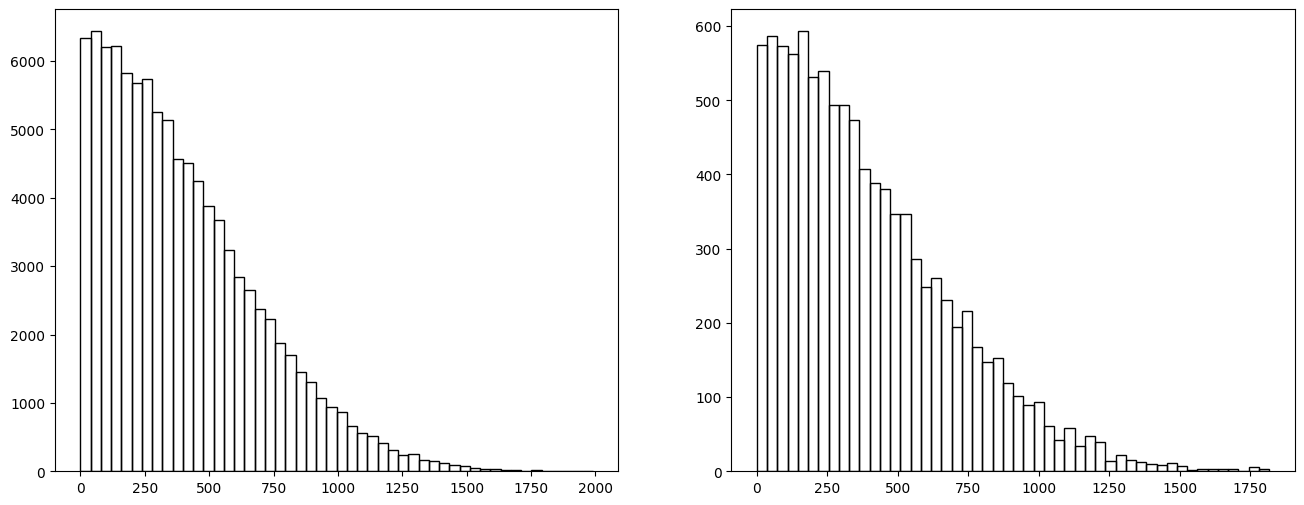

In [85]:
import matplotlib.pyplot as plt
dfls_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='from',
    target=10000,
    dfls=dfls).absences.distance(u_sections.sections.dissolve().geometry[0])
fig, ax = plt.subplots(figsize=(16, 6), ncols=2)
ax[0].hist(dfls, bins=50, facecolor='none', edgecolor='black');
ax[1].hist(dfls_absences, bins=50, facecolor='none', edgecolor='black');

#### Absences attributes

In [86]:
u_absences.name

'absences-fs-10000m-0day'

In [87]:
u_absences.parameters

{'absences_var': 'from',
 'absences_target': 20,
 'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 0,
 'presencezones_tm_unit': 'day'}

In [88]:
u_absences.absences

,point_id,point,date,section_id,dfbs,point_al
0,a01,POINT (568958.818 4742506.438),2019-01-25,s001,11138.585237,POINT (568955.6951284563 4742818.422224387)
1,a02,POINT (564252.786 4743047.827),2019-01-25,s001,15839.590722,POINT (564255.1762405325 4742791.838545119)
2,a03,POINT (535725.458 4743160.161),2019-01-25,s001,44368.543650,POINT (535728.0667013039 4742659.167684824)
3,a04,POINT (521495.566 4742718.039),2019-01-25,s001,58602.560236,POINT (521495.9358131948 4742600.039670152)
4,a05,POINT (506789.645 4742685.087),2019-01-25,s001,73309.614681,POINT (506789.79528755357 4742532.086587643)
5,a06,POINT (583574.843 4733111.073),2019-01-30,s002,89366.731447,POINT (583568.2948282715 4733651.033398683)
6,a07,POINT (559201.879 4733450.132),2019-01-30,s002,113736.458947,POINT (559201.20319632 4733529.128970264)
7,a08,POINT (546569.815 4733924.067),2019-01-30,s002,126365.615518,POINT (546572.8689476431 4733469.077658116)
8,a09,POINT (541214.487 4732635.013),2019-01-30,s002,131728.890211,POINT (541209.7026653597 4733434.998217192)
9,a10,POINT (547397.464 4713963.251),2019-03-02,s003,219600.077822,POINT (547390.4744584779 4714985.226756614)


#### ```Absences.save```

In [89]:
u_absences.save(
    folder=export_folder, 
    crs_export='EPSG:4326')

Success: reprojected to CRS "EPSG:4326"


#### ```Absences.open```

In [90]:
u_absences = Absences.open(
    export_folder, 
    basename='absences-fs-10000m-0day', 
    crs_working='EPSG:32619')  

Success: file opened.
Success: file opened.
Success: reprojected to CRS "EPSG:32619"


#### ```Absences.plot```

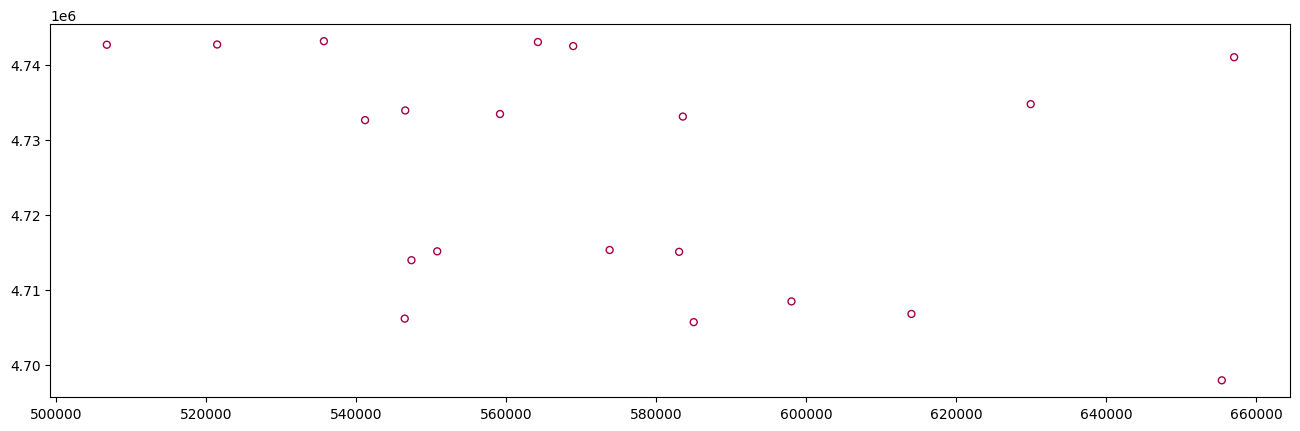

In [91]:
u_absences.plot()